<a href="https://colab.research.google.com/github/MuhammadAqsandy/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 – Exploratory Data Analysis (EDA)

## 📖 Summary
Chapter 1 introduces the foundational techniques of **Exploratory Data Analysis (EDA)** — the practice of summarizing, visualizing, and understanding data *before* formal modeling. The chapter emphasizes that EDA is not just a preliminary step but a critical thinking process to uncover structure, anomalies, and relationships in data.

### Key Topics Covered:
1. **Estimates of Location** – mean, median, trimmed mean, weighted mean
2. **Estimates of Variability** – variance, standard deviation, IQR, MAD
3. **Exploring Data Distribution** – percentiles, boxplots, frequency tables, histograms
4. **Exploring Binary & Categorical Data** – mode, bar charts
5. **Correlation** – Pearson, Spearman correlation matrices
6. **Exploring Two or More Variables** – scatter plots, hexagonal binning, violin plots

---


## 1. Setup & Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Use a classic dataset for demonstration
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# State population & murder rate dataset (mimicking book's dataset)
state = pd.DataFrame({
    'State': ['Alabama','Alaska','Arizona','Arkansas','California','Colorado',
              'Connecticut','Delaware','Florida','Georgia','Hawaii','Idaho',
              'Illinois','Indiana','Iowa','Kansas','Kentucky','Louisiana',
              'Maine','Maryland'],
    'Population': [4779736,710231,6392017,2915918,37253956,5029196,
                   3574097,897934,18801310,9687653,1360301,1567582,
                   12830632,6483802,3046355,2853118,4339367,4533372,
                   1328361,5773552],
    'Murder.Rate': [5.7,5.6,4.7,5.6,4.4,2.8,2.4,5.8,5.8,5.7,
                    1.8,2.0,5.3,5.0,1.9,3.7,3.6,10.3,1.6,6.1],
    'Abbreviation': ['AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
                     'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD']
})

print(state.head())
print(f"\nShape: {state.shape}")


        State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA

Shape: (20, 4)


## 2. Estimates of Location

In [3]:
# ── Mean ──
mean_pop = state['Population'].mean()
print(f"Mean Population: {mean_pop:,.0f}")

# ── Trimmed Mean (10%) ──
trimmed_mean = stats.trim_mean(state['Population'], 0.1)
print(f"Trimmed Mean (10%): {trimmed_mean:,.0f}")

# ── Weighted Mean ──
weighted_mean = np.average(state['Murder.Rate'], weights=state['Population'])
print(f"Weighted Mean Murder Rate: {weighted_mean:.4f}")

# ── Median ──
median_pop = state['Population'].median()
print(f"Median Population: {median_pop:,.0f}")


Mean Population: 6,707,924
Trimmed Mean (10%): 4,780,941
Weighted Mean Murder Rate: 4.8872
Median Population: 4,436,370


### 📚 Theory: Estimates of Location
- **Mean** $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — sensitive to outliers.
- **Trimmed Mean** — drops the top and bottom $p\%$ before averaging; robust to extremes.
- **Weighted Mean** $\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$ — useful when observations have different importance.
- **Median** — the middle value; robust measure of center, less influenced by outliers.


## 3. Estimates of Variability

In [4]:
# ── Variance & Standard Deviation ──
print(f"Variance:           {state['Population'].var():,.0f}")
print(f"Std Deviation:      {state['Population'].std():,.0f}")

# ── IQR (Interquartile Range) ──
Q1 = state['Population'].quantile(0.25)
Q3 = state['Population'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR:                {IQR:,.0f}")

# ── MAD (Median Absolute Deviation) ──
MAD = (state['Population'] - state['Population'].median()).abs().median()
print(f"MAD:                {MAD:,.0f}")

# ── Percentiles ──
print("\nPercentiles:")
for p in [5, 25, 50, 75, 95]:
    print(f"  {p}th: {state['Population'].quantile(p/100):,.0f}")


Variance:           71,038,380,902,563
Std Deviation:      8,428,427
IQR:                3,883,229
MAD:                2,001,540

Percentiles:
  5th: 888,549
  25th: 2,531,734
  50th: 4,436,370
  75th: 6,414,963
  95th: 19,723,942


### 📚 Theory: Estimates of Variability
- **Variance** $s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$ — average squared deviation; sensitive to outliers.
- **Standard Deviation** $s = \sqrt{s^2}$ — same units as the data; widely used.
- **IQR** = Q3 − Q1 — range of the middle 50%; robust to outliers.
- **MAD** = Median(|$x_i$ − Median($x$)|) — robust alternative to std deviation.


## 4. Distribution – Histogram & Boxplot

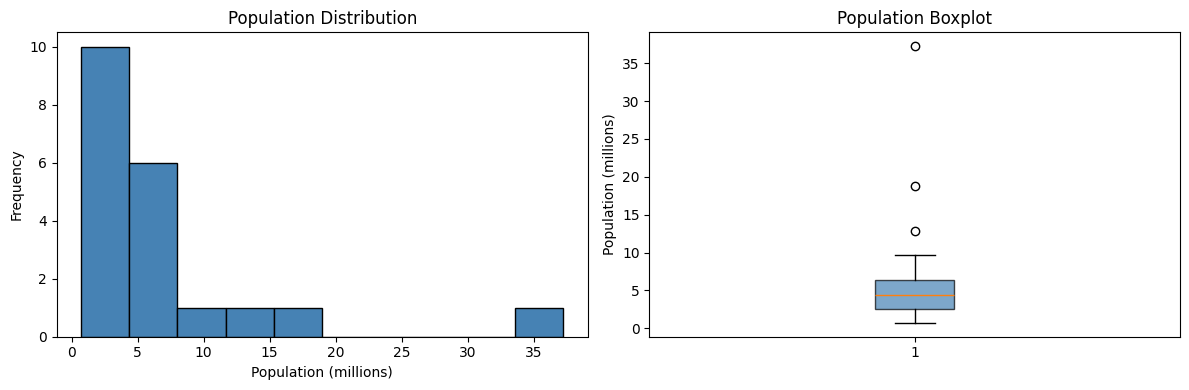

Saved: ch1_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(state['Population'] / 1_000_000, bins=10, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Population (millions)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Population Distribution')

# Boxplot
axes[1].boxplot(state['Population'] / 1_000_000, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('Population (millions)')
axes[1].set_title('Population Boxplot')

plt.tight_layout()
plt.savefig('ch1_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: ch1_distribution.png")



## 5. Correlation

Pearson Correlation Matrix:
       AAPL   MSFT   GOOG   AMZN
AAPL  1.000 -0.875  0.449 -0.816
MSFT -0.875  1.000 -0.271  0.911
GOOG  0.449 -0.271  1.000 -0.251
AMZN -0.816  0.911 -0.251  1.000


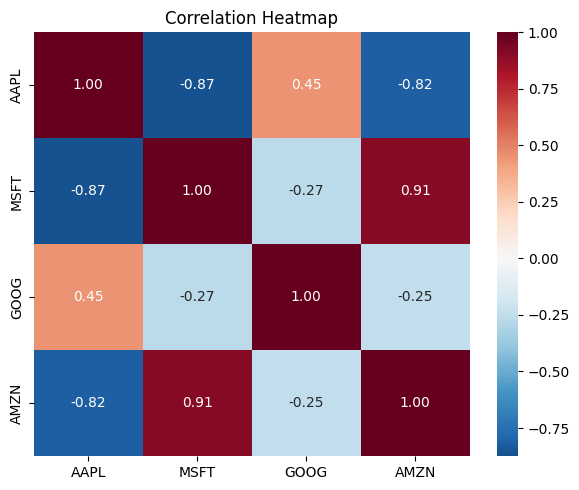

In [6]:
# Pearson Correlation
sp500 = pd.DataFrame(np.random.randn(100, 4), columns=['AAPL','MSFT','GOOG','AMZN'])
sp500 = sp500.cumsum() + 100  # simulate stock prices

corr_matrix = sp500.corr()
print("Pearson Correlation Matrix:")
print(corr_matrix.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('ch1_correlation.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Correlation
- **Pearson's r** measures the *linear* relationship between two variables: $r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{(n-1)s_x s_y}$, ranging from −1 to +1.
- **Spearman's ρ** is a rank-based correlation, robust to outliers and non-linear monotonic relationships.
- A correlation of 0 does not imply independence — only the absence of *linear* relationship.


## 6. Scatter Plot & Two-Variable Exploration

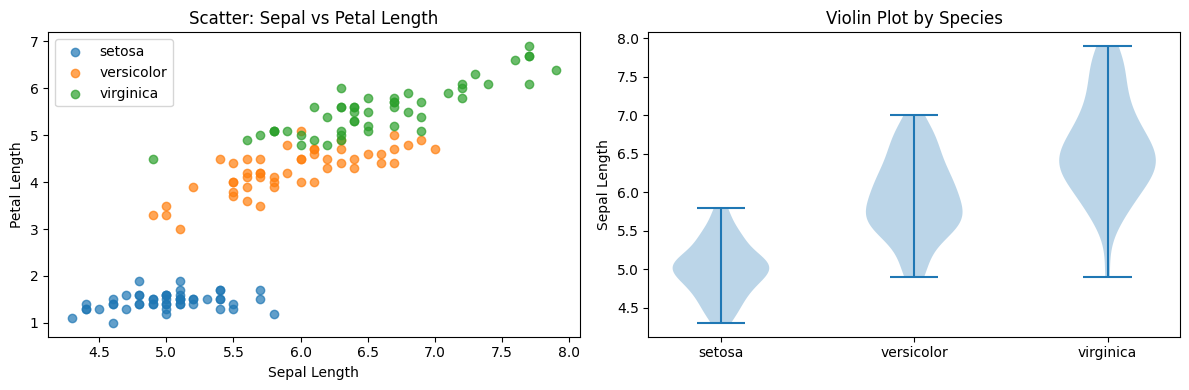

In [7]:
iris = load_iris(as_frame=True)['frame']
iris.columns = [*load_iris().feature_names, 'target']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
for t, name in enumerate(['setosa','versicolor','virginica']):
    mask = iris['target'] == t
    axes[0].scatter(iris.loc[mask,'sepal length (cm)'],
                    iris.loc[mask,'petal length (cm)'],
                    label=name, alpha=0.7)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')
axes[0].set_title('Scatter: Sepal vs Petal Length')
axes[0].legend()

# Violin plot
axes[1].violinplot([iris.loc[iris['target']==t, 'sepal length (cm)'] for t in range(3)],
                   positions=[0,1,2])
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['setosa','versicolor','virginica'])
axes[1].set_ylabel('Sepal Length')
axes[1].set_title('Violin Plot by Species')

plt.tight_layout()
plt.savefig('ch1_scatter.png', dpi=100, bbox_inches='tight')
plt.show()


## ✅ Chapter 1 Summary

| Concept | Key Metric | Robust? |
|---|---|---|
| Location | Mean | ❌ |
| Location | Median, Trimmed Mean | ✅ |
| Variability | Std Dev, Variance | ❌ |
| Variability | IQR, MAD | ✅ |
| Distribution | Histogram, Boxplot, Violin | — |
| Relationship | Pearson r, Spearman ρ | Partial |

EDA is not just descriptive — it guides feature selection, preprocessing decisions, and model choice.
